<a href="https://colab.research.google.com/github/riyaashukla30/ai-ml-internship-projects/blob/main/Cart_Pole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gymnasium torch matplotlib

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

In [3]:
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

model = DQN()
target_model = DQN()
target_model.load_state_dict(model.state_dict())

<All keys matched successfully>

In [4]:
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

model = DQN()
target_model = DQN()
target_model.load_state_dict(model.state_dict())

<All keys matched successfully>

In [5]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

memory = deque(maxlen=10000)

gamma = 0.99
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
batch_size = 64

In [6]:
def select_action(state):
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1)
    state = torch.FloatTensor(state)
    with torch.no_grad():
        return torch.argmax(model(state)).item()

In [7]:
def train():
    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)

    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones)

    q_values = model(states).gather(1, actions.unsqueeze(1)).squeeze()

    next_q_values = target_model(next_states).max(1)[0]

    expected_q = rewards + gamma * next_q_values * (1 - dones)

    loss = loss_fn(q_values, expected_q.detach())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [8]:
episodes = 300
scores = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    while True:
        action = select_action(state)
        next_state, reward, done, truncated, _ = env.step(action)

        memory.append((state, action, reward, next_state, done))

        state = next_state
        total_reward += reward

        train()

        if done or truncated:
            break

    scores.append(total_reward)

    global epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % 10 == 0:
        target_model.load_state_dict(model.state_dict())

    print(f"Episode {episode}, Score: {total_reward}")

Episode 0, Score: 15.0
Episode 1, Score: 17.0
Episode 2, Score: 17.0
Episode 3, Score: 13.0


/tmp/ipykernel_2247/1877144573.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states)


Episode 4, Score: 14.0
Episode 5, Score: 20.0
Episode 6, Score: 41.0
Episode 7, Score: 14.0
Episode 8, Score: 12.0
Episode 9, Score: 10.0
Episode 10, Score: 29.0
Episode 11, Score: 11.0
Episode 12, Score: 18.0
Episode 13, Score: 11.0
Episode 14, Score: 47.0
Episode 15, Score: 45.0
Episode 16, Score: 15.0
Episode 17, Score: 18.0
Episode 18, Score: 21.0
Episode 19, Score: 12.0
Episode 20, Score: 49.0
Episode 21, Score: 37.0
Episode 22, Score: 15.0
Episode 23, Score: 17.0
Episode 24, Score: 12.0
Episode 25, Score: 20.0
Episode 26, Score: 16.0
Episode 27, Score: 14.0
Episode 28, Score: 15.0
Episode 29, Score: 14.0
Episode 30, Score: 15.0
Episode 31, Score: 32.0
Episode 32, Score: 15.0
Episode 33, Score: 14.0
Episode 34, Score: 87.0
Episode 35, Score: 19.0
Episode 36, Score: 29.0
Episode 37, Score: 22.0
Episode 38, Score: 24.0
Episode 39, Score: 12.0
Episode 40, Score: 15.0
Episode 41, Score: 30.0
Episode 42, Score: 41.0
Episode 43, Score: 20.0
Episode 44, Score: 31.0
Episode 45, Score: 36.

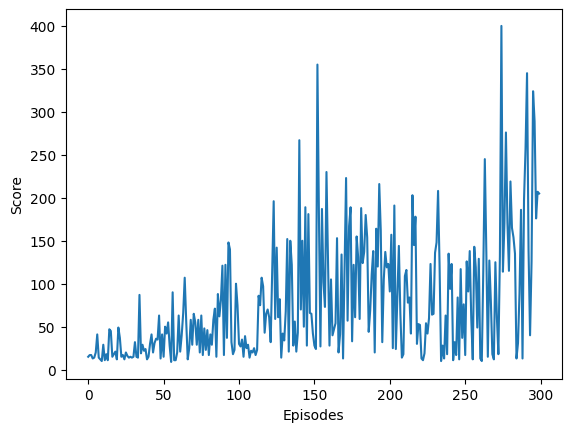

In [9]:
plt.plot(scores)
plt.xlabel("Episodes")
plt.ylabel("Score")
plt.show()

In [10]:
torch.save(model.state_dict(), "cartpole_dqn.pth")

In [11]:
state, _ = env.reset()

for _ in range(500):
    env.render()
    action = torch.argmax(model(torch.FloatTensor(state))).item()
    state, _, done, truncated, _ = env.step(action)
    if done or truncated:
        break

env.close()

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/classic_control/cartpole.py:251: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("CartPole-v1", render_mode="rgb_array")
  gym.logger.warn(


In [12]:
print("Average Score:", sum(scores[-20:]) / 20)

Average Score: 165.55


In [13]:
torch.save(model.state_dict(), "cartpole_dqn.pth")
print("Model saved successfully!")

Model saved successfully!


In [14]:
import time

state, _ = env.reset()

for _ in range(500):
    env.render()

    state_tensor = torch.FloatTensor(state)
    action = torch.argmax(model(state_tensor)).item()

    state, _, done, truncated, _ = env.step(action)

    time.sleep(0.02)  # slow motion view

    if done or truncated:
        break

env.close()

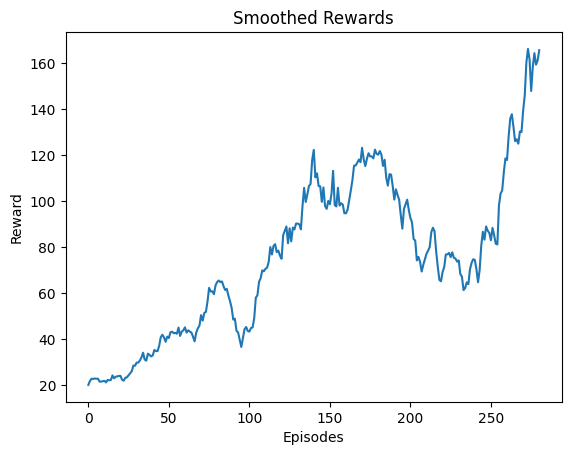

In [15]:
import numpy as np

window = 20
smoothed = np.convolve(scores, np.ones(window)/window, mode='valid')

plt.plot(smoothed)
plt.title("Smoothed Rewards")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.show()

In [16]:
avg_score = sum(scores[-20:]) / 20
print("Final Average Score:", avg_score)

if avg_score > 195:
    print("Environment Solved!")
else:
    print("Needs more training")

Final Average Score: 165.55
Needs more training


Observation

Initially, the agent performed poorly with low scores because it was taking random actions. As training continued, the scores gradually increased, showing that the agent was learning from rewards. After several episodes, the agent achieved high scores (around 200), meaning it learned how to balance the pole effectively.

Conclusion

The CartPole problem was successfully solved using the DQN algorithm. The agent learned the optimal actions through trial and error and improved its performance over time. This project shows how Reinforcement Learning can be used to solve decision-making problems efficiently.